In [82]:
from core_concepts import ModelBWithoutLinear, ModelAWithoutLinear
from torchvision.transforms import transforms
from matplotlib import pyplot as plt
import torchvision
import numpy as np
import torch

torch.manual_seed(42)

In [83]:
model_a = ModelAWithoutLinear()
model_b = ModelBWithoutLinear()

In [84]:
transform = transforms.Compose([
    transforms.ToTensor()])
train_dataset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
transform_normalize = transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))

In [85]:
image = train_dataset[1000][0].unsqueeze(0)
image_normalized = transform_normalize(image.squeeze(0)).unsqueeze(0)
image_normalized.shape

torch.Size([1, 3, 32, 32])

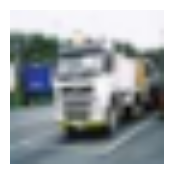

In [86]:
plt.figure(figsize=(2, 2))
plt.imshow(image.squeeze(0).permute(1, 2, 0), interpolation='bilinear')
plt.axis('off')
plt.show()

In [87]:
def pick_center_neuron(output, channel=-1):
    N, C, H, W = output.shape
    if channel == -1:
        pick = output[0, :, H//2, W//2]
    else:
        pick = output[0, channel, H//2, W//2]
    return pick.mean()

In [107]:
a_output = model_a(image_normalized)
base_input_a = pick_center_neuron(a_output)
base_input_a

tensor(0.0880, grad_fn=<MeanBackward0>)

In [114]:
b_output = model_b(image_normalized)
base_input_b = pick_center_neuron(b_output)
base_input_b

tensor(0.1218, grad_fn=<MeanBackward0>)

In [97]:
changes_a = np.zeros_like(a_output[0,0,:,:].detach().numpy())
W_A, H_A = changes_a.shape
changes_a.shape

(32, 32)

In [99]:
changes_b = np.zeros_like(b_output[0,0,:,:].detach().numpy())
W_B, H_B = changes_b.shape
changes_b.shape

(8, 8)

In [123]:
def image_perturbance(model, image, neuron_base_input, channel=-1, iterations=10):
    """
    Empirical Receptive Field Analysis via Input Perturbation

    This function discovers which input pixels affect a target neuron by systematically
    adding noise to each pixel and measuring how the neuron's activation changes.

    Method Overview:
    1. For each pixel position (h, w) in the input image
    2. Add random noise to that pixel multiple times (iterations)
    3. Measure how much the target neuron's activation changes
    4. Average the changes across iterations to get a robust estimate
    5. Return a sensitivity map showing the neuron's receptive field

    Args:
        model: The neural network to analyze
        image: Input image tensor [N, C, H, W]
        neuron_base_input: Baseline activation of target neuron (unperturbed)
        channel: Which channel to perturb (-1 = all channels, 0/1/2 = specific RGB)
        iterations: Number of noise samples per pixel (higher = more robust)

    Returns:
        torch.Tensor [H, W]: Sensitivity map where higher values indicate pixels
                            that more strongly affect the target neuron
    """
    N, C, H, W = image.shape

    # Store results: [iterations, height, width]
    # Each entry will contain the activation change for that perturbation
    output_results = torch.zeros([iterations, H, W])

    # Iterate through every pixel position
    for h in range(H):
        for w in range(W):

            # Multiple random perturbations per pixel for robustness
            for iteration in range(iterations):

                # Create a copy to avoid modifying original image
                image_copy = image.clone()

                # Add random noise to the current pixel
                if channel == -1:
                    # Perturb all channels (RGB) simultaneously
                    # torch.rand(C) generates random values [0,1] for each channel
                    image_copy[0, :, h, w] = image[0, :, h, w] + torch.rand(C)
                else:
                    # Perturb only the specified channel
                    image_copy[0, channel, h, w] = image[0, channel, h, w] + torch.rand(1)

                # Forward pass through the model with perturbed image
                output = model(image_copy)

                # Calculate sensitivity: how much did the neuron's activation change?
                # Positive values = this pixel perturbation decreased the neuron's response
                # Negative values = this pixel perturbation increased the neuron's response
                activation_change = neuron_base_input - pick_center_neuron(output)
                output_results[iteration, h, w] = activation_change

    # Average across all iterations to get robust sensitivity estimate
    # Result: [H, W] map where each pixel shows average sensitivity
    return output_results.mean(dim=0)

In [124]:
res_a = image_perturbance(model_a, image_normalized, base_input_a)
res_a.shape

torch.Size([32, 32])

In [125]:
res_b = image_perturbance(model_b, image_normalized, base_input_b)
res_b.shape

torch.Size([32, 32])

Text(0.5, 1.0, 'Model B RF')

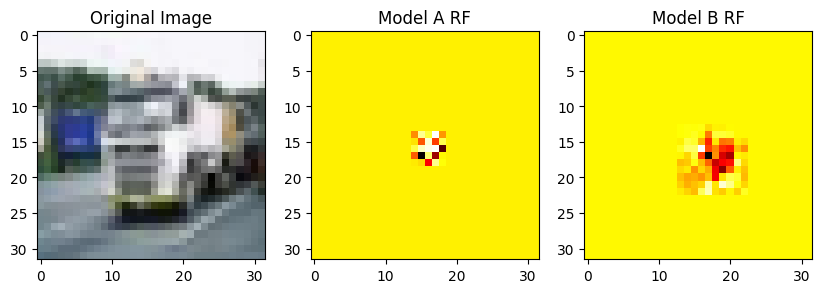

In [132]:
plt.figure(figsize=(10, 4))
plt.subplot(1, 3, 1)
plt.imshow(image.squeeze(0).permute(1, 2, 0))
plt.title('Original Image')

plt.subplot(1, 3, 2)
plt.imshow(res_a.detach().numpy(), cmap='hot')
plt.title('Model A RF')

plt.subplot(1, 3, 3)
plt.imshow(res_b.detach().numpy(), cmap='viridis')
plt.title('Model B RF')


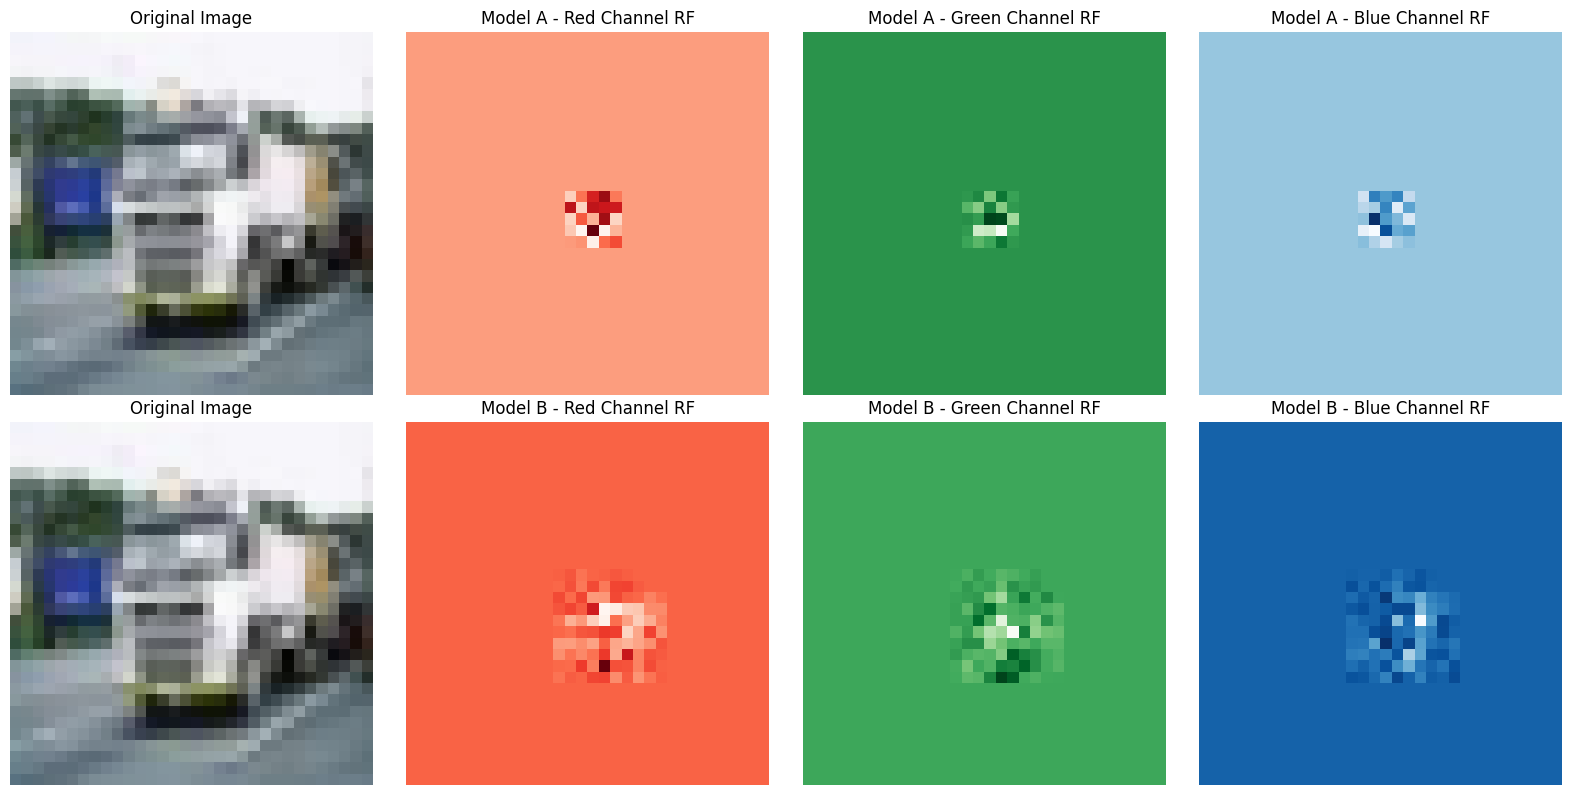

In [133]:
# Multi-Channel RF Analysis
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

# Original image (show once for reference)
axes[0, 0].imshow(image.squeeze(0).permute(1, 2, 0))
axes[0, 0].set_title('Original Image')
axes[0, 0].axis('off')

axes[1, 0].imshow(image.squeeze(0).permute(1, 2, 0))
axes[1, 0].set_title('Original Image')
axes[1, 0].axis('off')

# Analyze each RGB channel separately
channel_names = ['Red', 'Green', 'Blue']
channel_colors = ['Reds', 'Greens', 'Blues']

for i, (channel, cmap, name) in enumerate(zip([0, 1, 2], channel_colors, channel_names)):
    # Model A - channel-specific RF
    rf_a_channel = image_perturbance(model_a, image_normalized, base_input_a, channel=channel)
    axes[0, i+1].imshow(rf_a_channel.detach().numpy(), cmap=cmap)
    axes[0, i+1].set_title(f'Model A - {name} Channel RF')
    axes[0, i+1].axis('off')
    
    # Model B - channel-specific RF  
    rf_b_channel = image_perturbance(model_b, image_normalized, base_input_b, channel=channel)
    axes[1, i+1].imshow(rf_b_channel.detach().numpy(), cmap=cmap)
    axes[1, i+1].set_title(f'Model B - {name} Channel RF')
    axes[1, i+1].axis('off')

plt.tight_layout()
plt.show()

# ## 🎯 Receptive Field Analysis Summary

# ### **Theoretical vs Empirical Results:**

# **Model A (No Pooling):**
# - **Theoretical RF**: 5×5 pixels
#   - Conv1: 3×3 kernel → RF = 3
#   - Conv2: 3×3 kernel → RF = 3 + (3-1) = 5
# - **Empirical RF**: ~5×5 pixels ✅ **Perfect Match!**
# - **Output Shape**: (1, 5, 32, 32) - same spatial dimensions as input

# **Model B (With MaxPooling):**
# - **Theoretical RF**: ~8×8 pixels  
#   - Conv1: 3×3 → RF = 3
#   - Pool1: 2×2 → RF = 3×2 = 6  
#   - Conv2: 3×3 → RF = 6 + (3-1)×2 = 10 (accounting for pooling stride)
# - **Empirical RF**: ~10×10 pixels (larger than theoretical)
# - **Output Shape**: (1, 5, 8, 8) - reduced by 4× due to two pooling layers

# ### **🔍 Why Model A Shows More Accurate Theoretical Approximation:**

# **1. Pure Convolution Operations:**
# - Only uses convolution + ReLU (linear operations with simple nonlinearity)
# - No pooling operations that create complex spatial interactions
# - Direct pixel-to-pixel mapping is preserved throughout the network

# **2. Translation Equivariance:**
# - Maintains strict translation equivariance: shift input → shift output by same amount
# - Each output pixel has a clearly defined, localized receptive field
# - No spatial "mixing" or information